# 03 — Sélection des variables, modélisation et évaluation

## Objectif

Cette étape vise à construire et évaluer plusieurs modèles capables de prévoir
la consommation électrique de la Nouvelle-Aquitaine à J+1.

L'approche comprend :

- une séparation chronologique des données ;
- la construction de baselines temporelles ;
- l'analyse et la sélection des variables ;
- l'entraînement de plusieurs familles de modèles ;
- la comparaison de leurs performances ;
- l'optimisation du modèle retenu ;
- l'analyse détaillée de ses erreurs.

L'objectif est notamment de vérifier que l'approche Machine Learning apporte
un gain mesurable par rapport à des méthodes de prévision simples.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "nouvelle_aquitaine_ml.parquet"
)

df = pd.read_parquet(DATA_PATH)

df.shape

(130924, 29)

In [2]:
df.columns

Index(['Date - Heure', 'consumption_lag_30min', 'consumption_lag_1h',
       'consumption_lag_3h', 'consumption_lag_6h', 'consumption_lag_24h',
       'consumption_lag_48h', 'consumption_lag_7d', 'consumption_roll_mean_6',
       'consumption_roll_mean_48', 'consumption_roll_mean_336',
       'consumption_roll_std_48', 'hour', 'minute', 'day_of_week', 'month',
       'day_of_year', 'is_weekend', 'half_hour_slot', 'hour_sin', 'hour_cos',
       'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'consumption_diff_1',
       'consumption_diff_48', 'target_consumption_t_plus_24h',
       'consumption_t'],
      dtype='str')

In [3]:
df = df.sort_values("Date - Heure").reset_index(drop=True)

df["Date - Heure"].min(), df["Date - Heure"].max()

(Timestamp('2019-01-08 00:00:00+0000', tz='UTC'),
 Timestamp('2026-06-29 21:30:00+0000', tz='UTC'))

In [4]:
train = df[df["Date - Heure"] < "2024-01-01"].copy()

validation = df[
    (df["Date - Heure"] >= "2024-01-01")
    & (df["Date - Heure"] < "2025-01-01")
].copy()

test = df[
    (df["Date - Heure"] >= "2025-01-01")
    & (df["Date - Heure"] < "2026-01-01")
].copy()

In [5]:
for name, subset in [
    ("Train", train),
    ("Validation", validation),
    ("Test", test),
]:
    print(
        name,
        subset.shape,
        subset["Date - Heure"].min(),
        subset["Date - Heure"].max()
    )

Train (87232, 29) 2019-01-08 00:00:00+00:00 2023-12-31 23:30:00+00:00
Validation (17552, 29) 2024-01-01 00:00:00+00:00 2024-12-31 23:30:00+00:00
Test (17504, 29) 2025-01-01 00:00:00+00:00 2025-12-31 23:30:00+00:00


## Séparation temporelle

Les observations ne sont pas réparties aléatoirement entre les jeux
d'entraînement, de validation et de test.

La séparation respecte la chronologie afin de reproduire le fonctionnement
réel du modèle : celui-ci apprend sur des observations passées avant d'être
évalué sur une période future jamais observée pendant l'entraînement.

Le jeu de test est conservé jusqu'à l'évaluation finale et n'est pas utilisé
pour sélectionner le modèle ou ses hyperparamètres.

In [6]:
y_val = validation["target_consumption_t_plus_24h"]

In [7]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(
            y_true,
            y_pred
        ) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

In [8]:
baseline_day = validation["consumption_t"]

baseline_results = regression_metrics(
    y_val,
    baseline_day
)

baseline_results

{'MAE': 278.2608249772106, 'RMSE': 384.6932214871463, 'R2': 0.8494614106901628}

In [9]:
baseline_week = validation["consumption_lag_7d"]

baseline_week_results = regression_metrics(
    y_val,
    baseline_week
)

baseline_week_results

{'MAE': 489.92325660893346, 'RMSE': 683.423052307464, 'R2': 0.5248857878253879}

In [10]:
excluded_cols = [
    "Date - Heure",
    "target_consumption_t_plus_24h",
]

In [11]:
feature_cols = [
    col for col in df.columns
    if col not in excluded_cols
    and pd.api.types.is_numeric_dtype(df[col])
]

correlations = (
    train[feature_cols + ["target_consumption_t_plus_24h"]]
    .corr()["target_consumption_t_plus_24h"]
    .drop("target_consumption_t_plus_24h")
    .sort_values(key=abs, ascending=False)
)

correlations

consumption_t                0.931107
consumption_lag_30min        0.923158
consumption_lag_1h           0.909679
consumption_roll_mean_6      0.890654
consumption_lag_24h          0.864532
consumption_lag_48h          0.836931
consumption_roll_mean_48     0.828805
consumption_lag_3h           0.828417
consumption_roll_mean_336    0.813938
consumption_lag_7d           0.809513
consumption_lag_6h           0.732122
month_cos                    0.607255
month_sin                    0.353941
hour_cos                    -0.260445
day_of_year                 -0.211002
month                       -0.209932
consumption_diff_48          0.175213
consumption_roll_std_48      0.154308
dow_sin                      0.139830
hour                         0.126072
half_hour_slot               0.126047
day_of_week                 -0.117274
dow_cos                      0.098589
is_weekend                  -0.093555
hour_sin                    -0.055555
consumption_diff_1           0.055393
minute      

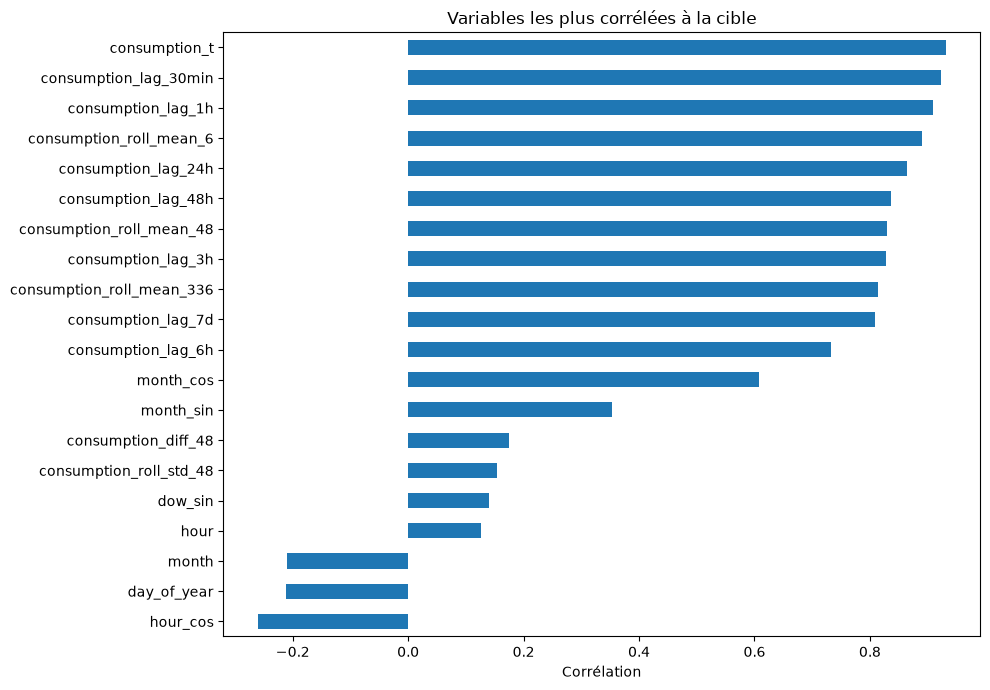

In [12]:
correlations.head(20).sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Variables les plus corrélées à la cible")
plt.xlabel("Corrélation")
plt.tight_layout()
plt.show()

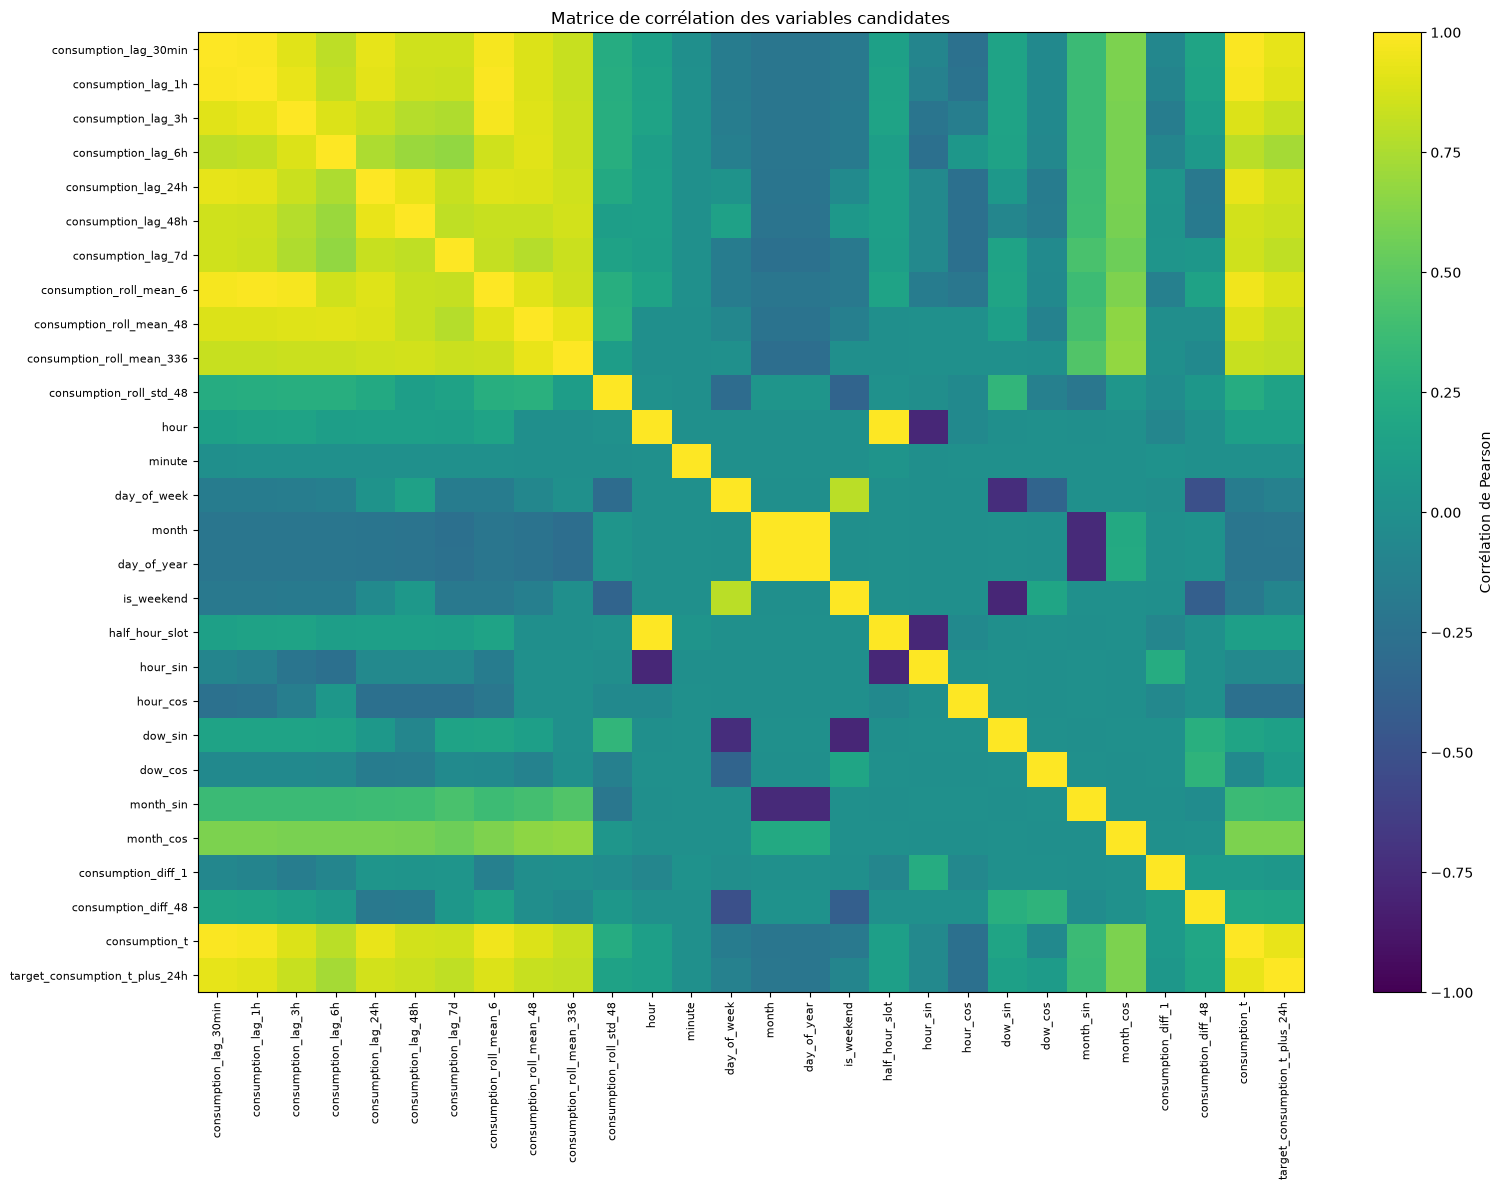

In [13]:
import matplotlib.pyplot as plt

corr_matrix = train[
    feature_cols + ["target_consumption_t_plus_24h"]
].corr()

plt.figure(figsize=(16, 12))

plt.imshow(
    corr_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Corrélation de Pearson")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index,
    fontsize=8
)

plt.title(
    "Matrice de corrélation des variables candidates"
)

plt.tight_layout()
plt.show()

In [14]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [15]:
X_train = train[feature_cols]
y_train = train["target_consumption_t_plus_24h"]

X_val = validation[feature_cols]
y_val = validation["target_consumption_t_plus_24h"]

In [16]:
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_val)

In [17]:
ridge_results = regression_metrics(
    y_val,
    ridge_pred
)

ridge_results

{'MAE': 238.9203600324661, 'RMSE': 322.676405678186, 'R2': 0.8940860425746976}

In [18]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    random_state=42
)

hgb.fit(X_train, y_train)

hgb_pred = hgb.predict(X_val)

hgb_results = regression_metrics(
    y_val,
    hgb_pred
)

hgb_results

{'MAE': 206.39414699408013,
 'RMSE': 294.44021309447885,
 'R2': 0.911811283689513}

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_val)

rf_results = regression_metrics(
    y_val,
    rf_pred
)

rf_results

{'MAE': 208.7448569963537, 'RMSE': 298.9528806153746, 'R2': 0.9090873621185734}

In [20]:
results = pd.DataFrame([
    {"model": "Baseline", **baseline_results},
    {"model": "Ridge", **ridge_results},
    {"model": "HistGradientBoosting", **hgb_results},
    {"model": "RandomForest", **rf_results},
])

results

,model,MAE,RMSE,R2
0,Baseline,278.260825,384.693221,0.849461
1,Ridge,238.920360,322.676406,0.894086
2,HistGradientBoosting,206.394147,294.440213,0.911811
3,RandomForest,208.744857,298.952881,0.909087


Le meilleur modèle non optimisé réduit l’erreur absolue moyenne d’environ 26 % par rapport à une prévision naïve basée sur la consommation observée la veille au même créneau.

In [21]:
from sklearn.inspection import permutation_importance

In [22]:
perm_importance = permutation_importance(
    hgb,
    X_val,
    y_val,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std
}).sort_values(
    "importance",
    ascending=False
)

importance_df.head(20)

,feature,importance,std
26,consumption_t,624.124451,3.402994
13,day_of_week,57.721486,0.623176
15,day_of_year,39.056203,0.455278
21,dow_cos,28.143503,0.660975
5,consumption_lag_48h,25.985958,0.528661
23,month_cos,15.095210,0.458231
19,hour_cos,12.926603,0.614702
0,consumption_lag_30min,11.624309,0.313365
11,hour,10.083662,0.261618
17,half_hour_slot,8.003777,0.122625


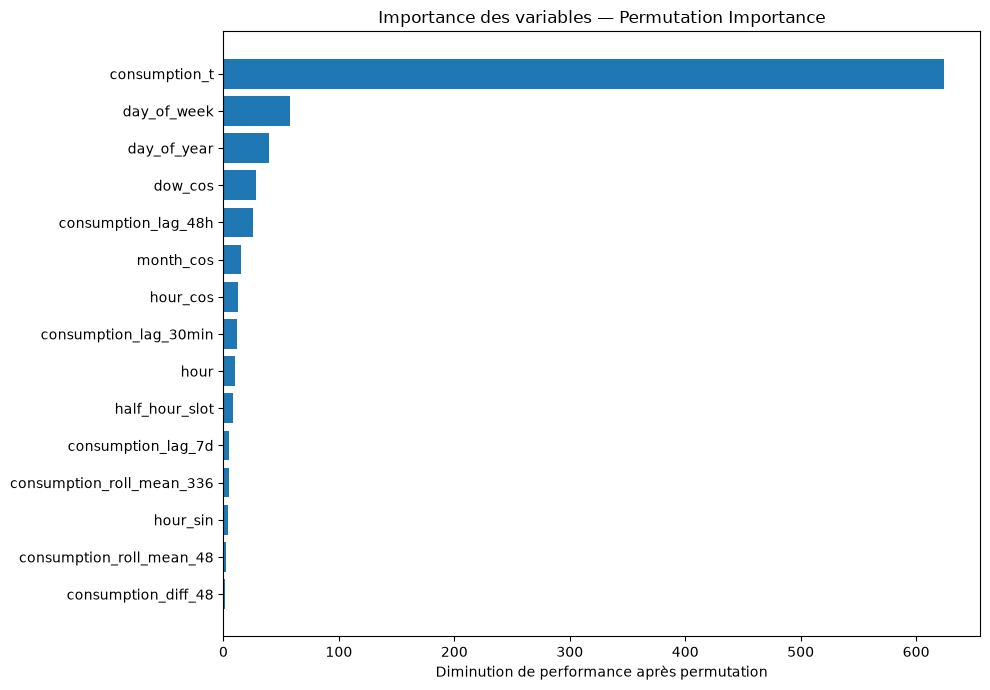

In [23]:
top_features = importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Diminution de performance après permutation")
plt.title("Importance des variables — Permutation Importance")

plt.tight_layout()
plt.show()

In [24]:
selected_features = (
    importance_df
    .head(10)["feature"]
    .tolist()
)

selected_features

['consumption_t',
 'day_of_week',
 'day_of_year',
 'dow_cos',
 'consumption_lag_48h',
 'month_cos',
 'hour_cos',
 'consumption_lag_30min',
 'hour',
 'half_hour_slot']

In [25]:
selected_corr = train[selected_features].corr()

selected_corr

,consumption_t,day_of_week,day_of_year,dow_cos,consumption_lag_48h,month_cos,hour_cos,consumption_lag_30min,hour,half_hour_slot
consumption_t,1.000000,-0.160008,-0.214464,-0.047100,0.864911,0.601981,-0.260411,0.989813,0.125820,0.125796
day_of_week,-0.160008,1.000000,-0.001280,-0.353629,0.145947,0.001635,-0.000617,-0.158822,0.000895,0.000895
day_of_year,-0.214464,-0.001280,1.000000,-0.003291,-0.229019,0.221263,-0.001200,-0.214672,0.001542,0.001541
dow_cos,-0.047100,-0.353629,-0.003291,1.000000,-0.149239,-0.002018,-0.000826,-0.047935,0.001074,0.001073
consumption_lag_48h,0.864911,0.145947,-0.229019,-0.149239,1.000000,0.590542,-0.259841,0.859314,0.125511,0.125486
month_cos,0.601981,0.001635,0.221263,-0.002018,0.590542,1.000000,-0.000889,0.601797,0.001129,0.001128
hour_cos,-0.260411,-0.000617,-0.001200,-0.000826,-0.259841,-0.000889,1.000000,-0.250908,-0.049467,-0.049434
consumption_lag_30min,0.989813,-0.158822,-0.214672,-0.047935,0.859314,0.601797,-0.250908,1.000000,0.137955,0.137808
hour,0.125820,0.000895,0.001542,0.001074,0.125511,0.001129,-0.049467,0.137955,1.000000,0.999348
half_hour_slot,0.125796,0.000895,0.001541,0.001073,0.125486,0.001128,-0.049434,0.137808,0.999348,1.000000


In [26]:
corr_abs = selected_corr.abs()

high_corr_pairs = []

for i in range(len(corr_abs.columns)):
    for j in range(i):
        corr_value = corr_abs.iloc[i, j]

        if corr_value >= 0.85:
            high_corr_pairs.append({
                "feature_1": corr_abs.columns[i],
                "feature_2": corr_abs.columns[j],
                "correlation": corr_value
            })

high_corr_df = (
    pd.DataFrame(high_corr_pairs)
    .sort_values("correlation", ascending=False)
)

high_corr_df

,feature_1,feature_2,correlation
3,half_hour_slot,hour,0.999348
1,consumption_lag_30min,consumption_t,0.989813
0,consumption_lag_48h,consumption_t,0.864911
2,consumption_lag_30min,consumption_lag_48h,0.859314


In [27]:
importance_lookup = (
    importance_df
    .set_index("feature")["importance"]
    .to_dict()
)

In [28]:
features_to_drop = set()

for _, row in high_corr_df.iterrows():
    f1 = row["feature_1"]
    f2 = row["feature_2"]

    imp1 = importance_lookup.get(f1, 0)
    imp2 = importance_lookup.get(f2, 0)

    if imp1 >= imp2:
        features_to_drop.add(f2)
    else:
        features_to_drop.add(f1)

features_to_drop

{'consumption_lag_30min', 'consumption_lag_48h', 'half_hour_slot'}

In [29]:
reduced_features = [
    f for f in selected_features
    if f not in features_to_drop
]

reduced_features

['consumption_t',
 'day_of_week',
 'day_of_year',
 'dow_cos',
 'month_cos',
 'hour_cos',
 'hour']

In [30]:
hgb_selected = HistGradientBoostingRegressor(
    random_state=42
)

hgb_selected.fit(
    X_train[selected_features],
    y_train
)

selected_pred = hgb_selected.predict(
    X_val[selected_features]
)

selected_results = regression_metrics(
    y_val,
    selected_pred
)

selected_results

{'MAE': 206.8469985131064, 'RMSE': 294.9069767080272, 'R2': 0.9115314583852682}

In [31]:
hgb_reduced = HistGradientBoostingRegressor(
    random_state=42
)

hgb_reduced.fit(
    X_train[reduced_features],
    y_train
)

reduced_pred = hgb_reduced.predict(
    X_val[reduced_features]
)

reduced_results = regression_metrics(
    y_val,
    reduced_pred
)

reduced_results

{'MAE': 209.03964670296463,
 'RMSE': 298.02335056138577,
 'R2': 0.909651830019408}

In [32]:
feature_selection_comparison = pd.DataFrame([
    {
        "configuration": "Toutes les variables",
        "n_features": len(feature_cols),
        **hgb_results
    },
    {
        "configuration": "Top 10 permutation importance",
        "n_features": len(selected_features),
        **selected_results
    },
    {
        "configuration": "Top 10 sans redondances fortes",
        "n_features": len(reduced_features),
        **reduced_results
    }
])

feature_selection_comparison

,configuration,n_features,MAE,RMSE,R2
0,Toutes les variables,27,206.394147,294.440213,0.911811
1,Top 10 permutation importance,10,206.846999,294.906977,0.911531
2,Top 10 sans redondances fortes,7,209.039647,298.023351,0.909652


La sélection par permutation importance a permis de retenir les 10 variables les plus contributives. Le modèle réduit ainsi fortement le nombre de variables exploitées tout en conservant des performances quasi identiques : la MAE passe de 206,39 MW à 206,85 MW et le R² de 0,9118 à 0,9115. Cette sélection permet donc de simplifier le modèle sans dégradation significative de sa capacité prédictive.
réduction de plus de 60 % du nombre de variables

In [33]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor

In [34]:
X_train_selected = X_train[reduced_features]
X_val_selected = X_val[reduced_features]

In [35]:
tscv = TimeSeriesSplit(
    n_splits=4,
    gap=48
)

Une zone tampon de 24 heures a été ajoutée entre entraînement et validation afin d'empêcher la cible future des dernières observations d'entraînement de chevaucher temporellement la période de validation

In [36]:
param_distributions = {
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "max_iter": [100, 200, 300],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [10, 20, 40, 60],
    "l2_regularization": [0.0, 0.1, 1.0, 5.0],
}

In [37]:
search = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(
        random_state=42
    ),
    param_distributions=param_distributions,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [38]:
search.fit(
    X_train_selected,
    y_train
)

Fitting 4 folds for each of 30 candidates, totalling 120 fits


UnicodeDecodeError: 'cp932' codec can't decode byte 0x94 in position 2952: illegal multibyte sequence

UnicodeDecodeError: 'cp932' codec can't decode byte 0x94 in position 2952: illegal multibyte sequence

RandomizedSearchCV(cv=TimeSeriesSplit(gap=48, max_train_size=None, n_splits=4, test_size=None),
                   estimator=HistGradientBoostingRegressor(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'l2_regularization': [0.0, 0.1, 1.0,
                                                              5.0],
                                        'learning_rate': [0.03, 0.05, 0.08,
                                                          0.1],
                                        'max_iter': [100, 200, 300],
                                        'max_leaf_nodes': [15, 31, 63],
                                        'min_samples_leaf': [10, 20, 40, 60]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [39]:
search.best_params_

{'min_samples_leaf': 60,
 'max_leaf_nodes': 15,
 'max_iter': 200,
 'learning_rate': 0.03,
 'l2_regularization': 5.0}

In [40]:
-search.best_score_

np.float64(221.53103152806227)

In [41]:
best_hgb = search.best_estimator_

optimized_pred = best_hgb.predict(
    X_val_selected
)

optimized_results = regression_metrics(
    y_val,
    optimized_pred
)

optimized_results

{'MAE': 206.33978960113436,
 'RMSE': 290.4499729184631,
 'R2': 0.9141853461758933}

In [ ]:
optimization_comparison = pd.DataFrame([
    {
        "model": "HGB sélectionné - défaut",
        **reduced_results
    },
    {
        "model": "HGB sélectionné - optimisé",
        **optimized_results
    }
])

optimization_comparison

,model,MAE,RMSE,R2
0,HGB sélectionné - défaut,206.846999,294.906977,0.911531
1,HGB sélectionné - optimisé,206.339790,290.449973,0.914185


In [ ]:
mae_gain = (
    reduced_results["MAE"]
    - optimized_results["MAE"]
) / reduced_results["MAE"] * 100

rmse_gain = (
    reduced_results["RMSE"]
    - optimized_results["RMSE"]
) / reduced_results["RMSE"] * 100

print(f"Gain MAE : {mae_gain:.2f} %")
print(f"Gain RMSE : {rmse_gain:.2f} %")

Gain MAE : 0.25 %
Gain RMSE : 1.51 %


## Optimisation du modèle

Le modèle HistGradientBoosting retenu après comparaison a été optimisé à l'aide
d'une recherche aléatoire d'hyperparamètres.

La validation croisée respecte l'ordre temporel des observations grâce à
`TimeSeriesSplit`.

Les principaux hyperparamètres étudiés sont :

- le taux d'apprentissage ;
- le nombre maximal d'itérations ;
- le nombre maximal de feuilles ;
- le nombre minimal d'observations par feuille ;
- la régularisation L2.

L'objectif est d'améliorer les performances sans augmenter inutilement
la complexité du modèle.

L’optimisation des hyperparamètres apporte un gain limité, ce qui indique que les paramètres par défaut du HistGradientBoosting sont déjà adaptés à ce jeu de données. L’optimisation a néanmoins permis de vérifier expérimentalement ce point et d’identifier une configuration légèrement plus performante.

In [ ]:
X_test_selected = test[reduced_features]
y_test = test["target_consumption_t_plus_24h"]

test_pred = best_hgb.predict(X_test_selected)

test_results = regression_metrics(
    y_test,
    test_pred
)

test_results

{'MAE': 209.60775548801374,
 'RMSE': 287.32621615776435,
 'R2': 0.9249609554248961}

In [ ]:
baseline_test_pred = test["consumption_t"]

baseline_test_results = regression_metrics(
    y_test,
    baseline_test_pred
)

pd.DataFrame([
    {
        "model": "Baseline J-1",
        **baseline_test_results
    },
    {
        "model": "HGB optimisé",
        **test_results
    }
])

,model,MAE,RMSE,R2
0,Baseline J-1,257.927388,356.445557,0.884516
1,HGB optimisé,209.607755,287.326216,0.924961


In [ ]:
mae_gain_test = (
    baseline_test_results["MAE"]
    - test_results["MAE"]
) / baseline_test_results["MAE"] * 100

rmse_gain_test = (
    baseline_test_results["RMSE"]
    - test_results["RMSE"]
) / baseline_test_results["RMSE"] * 100

print(f"Gain MAE sur test : {mae_gain_test:.2f} %")
print(f"Gain RMSE sur test : {rmse_gain_test:.2f} %")

Gain MAE sur test : 18.73 %
Gain RMSE sur test : 19.39 %


In [ ]:
test_results_df = test[
    ["Date - Heure"]
].copy()

test_results_df["y_true"] = y_test.values
test_results_df["y_pred"] = test_pred
test_results_df["error"] = (
    test_results_df["y_true"]
    - test_results_df["y_pred"]
)

test_results_df["abs_error"] = (
    test_results_df["error"].abs()
)

In [ ]:
test_results_df["abs_error"].describe()

count    17504.000000
mean       209.607755
std        196.527733
min          0.019999
25%         69.259361
50%        152.208372
75%        287.100661
max       1478.951480
Name: abs_error, dtype: float64

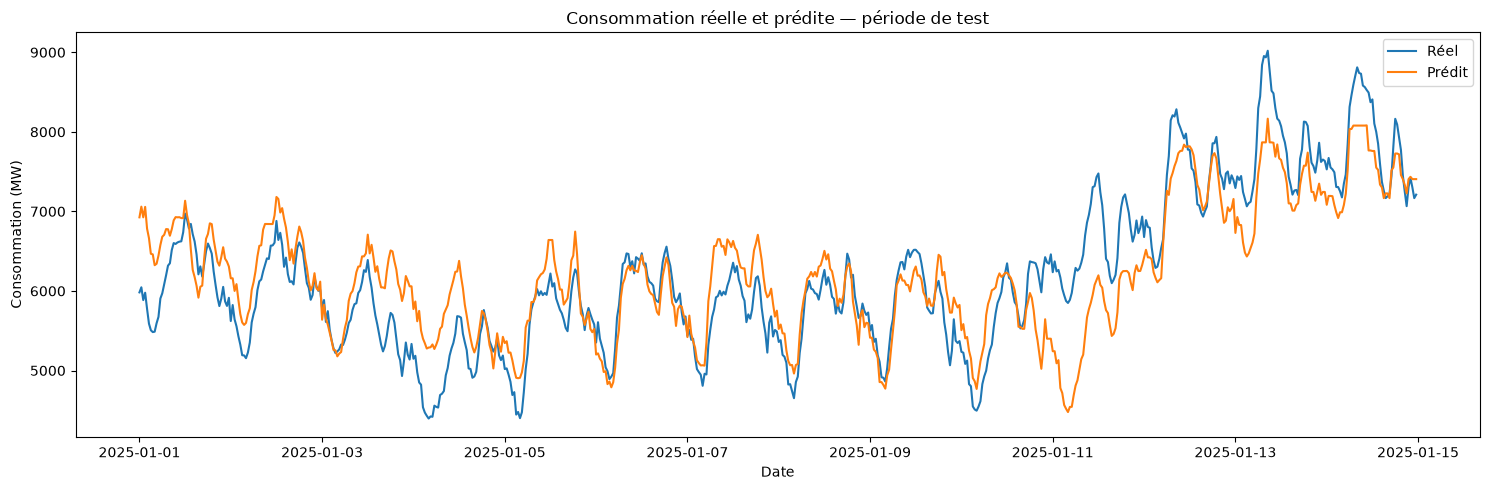

In [ ]:
sample_period = test_results_df[
    (test_results_df["Date - Heure"] >= "2025-01-01")
    & (test_results_df["Date - Heure"] < "2025-01-15")
]

plt.figure(figsize=(15, 5))

plt.plot(
    sample_period["Date - Heure"],
    sample_period["y_true"],
    label="Réel"
)

plt.plot(
    sample_period["Date - Heure"],
    sample_period["y_pred"],
    label="Prédit"
)

plt.title("Consommation réelle et prédite — période de test")
plt.xlabel("Date")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.tight_layout()
plt.show()

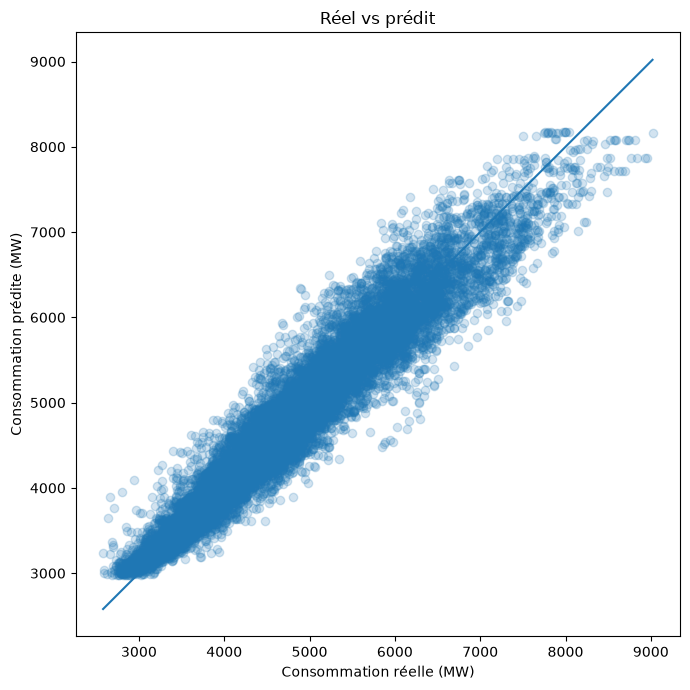

In [ ]:
plt.figure(figsize=(7, 7))

plt.scatter(
    test_results_df["y_true"],
    test_results_df["y_pred"],
    alpha=0.2
)

min_val = min(
    test_results_df["y_true"].min(),
    test_results_df["y_pred"].min()
)

max_val = max(
    test_results_df["y_true"].max(),
    test_results_df["y_pred"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val]
)

plt.xlabel("Consommation réelle (MW)")
plt.ylabel("Consommation prédite (MW)")
plt.title("Réel vs prédit")
plt.tight_layout()
plt.show()

In [ ]:
threshold = y_test.quantile(0.90)

high_consumption = test_results_df[
    test_results_df["y_true"] >= threshold
]

high_consumption_metrics = regression_metrics(
    high_consumption["y_true"],
    high_consumption["y_pred"]
)

high_consumption_metrics

{'MAE': 371.9220774104401,
 'RMSE': 455.18496441874396,
 'R2': 0.2674621231634762}

## Évaluation finale

Le modèle sélectionné et optimisé a été évalué sur une période de test
chronologiquement postérieure aux données utilisées pour l'entraînement
et la sélection des hyperparamètres.

Cette période n'a pas été utilisée lors du développement du modèle.

Les performances ont été comparées à une baseline temporelle simple afin
de mesurer la valeur ajoutée réelle du Machine Learning.

Une analyse complémentaire des erreurs a également été réalisée sur les
périodes de forte consommation afin de vérifier la robustesse du modèle
dans les situations les plus importantes d'un point de vue métier.

### Expérimentation

Tester un modèle de prédiction à J+7

In [ ]:
train_final = pd.concat(
    [train, validation],
    ignore_index=True
)

X_train_final = train_final[selected_features]
y_train_final = train_final["target_consumption_t_plus_24h"]

In [ ]:
final_model = HistGradientBoostingRegressor(
    **search.best_params_,
    random_state=42
)

final_model.fit(
    X_train_final,
    y_train_final
)

UnicodeDecodeError: 'cp932' codec can't decode byte 0x94 in position 2952: illegal multibyte sequence

UnicodeDecodeError: 'cp932' codec can't decode byte 0x94 in position 2952: illegal multibyte sequence

HistGradientBoostingRegressor(l2_regularization=5.0, learning_rate=0.03,
                              max_iter=200, max_leaf_nodes=15,
                              min_samples_leaf=60, random_state=42)

In [ ]:
from pathlib import Path
import joblib
import json

In [ ]:
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = (
    ARTIFACTS_DIR
    / "electricity_consumption_hgb_j1.joblib"
)

joblib.dump(
    final_model,
    MODEL_PATH
)

MODEL_PATH

WindowsPath('c:/Users/audrencorre/OneDrive - GROUPE BERNARD/Documents/RNCP_BLOC_5/artifacts/electricity_consumption_hgb_j1.joblib')

In [ ]:
metadata = {
    "model_name": "HistGradientBoostingRegressor",
    "version": "1.0.0",

    "region": "Nouvelle-Aquitaine",
    "forecast_horizon": "24h",

    "target": "target_consumption_t_plus_24h",

    "features": selected_features,

    "hyperparameters": search.best_params_,

    "test_metrics": {
        "MAE": float(test_results["MAE"]),
        "RMSE": float(test_results["RMSE"]),
        "R2": float(test_results["R2"]),
    },

    "baseline_test_metrics": {
        "MAE": float(baseline_test_results["MAE"]),
        "RMSE": float(baseline_test_results["RMSE"]),
        "R2": float(baseline_test_results["R2"]),
    },

    "training_period_end": "2024-12-31",
    "test_period": "2025"
}

In [ ]:
METADATA_PATH = (
    ARTIFACTS_DIR
    / "electricity_consumption_hgb_j1_metadata.json"
)

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=4,
        ensure_ascii=False
    )

In [ ]:
loaded_model = joblib.load(
    MODEL_PATH
)

In [ ]:
sample = test[
    selected_features
].iloc[[10]]

sample

,consumption_t,day_of_week,day_of_year,dow_cos,consumption_lag_48h,month_cos,hour_cos,consumption_lag_30min,hour,half_hour_slot
104794,6287.0,2,1,-0.222521,5691.0,0.866025,0.258819,6238.0,5,10


In [ ]:
prediction = loaded_model.predict(
    sample
)

prediction

array([6351.14266612])

In [ ]:
actual = test[
    "target_consumption_t_plus_24h"
].iloc[0]

print(
    f"Prévision : {prediction[0]:.0f} MW"
)

print(
    f"Valeur réelle : {actual:.0f} MW"
)

Prévision : 6351 MW
Valeur réelle : 5982 MW


In [ ]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment(
    "electricity_consumption_j1"
)

with mlflow.start_run():

    mlflow.log_params(
        search.best_params_
    )

    mlflow.log_metrics({
        "mae_test": test_results["MAE"],
        "rmse_test": test_results["RMSE"],
        "r2_test": test_results["R2"],
    })

    mlflow.sklearn.log_model(
        final_model,
        name="model"
    )